### Gerando os dados sintéticos

In [ ]:
import os
import re
import numpy as np
import pandas as pd

# Caminho da pasta raiz do caso OpenFOAM
case_dir = r"c:\Users\Welder\FOSSIL\Ashoori2\Kc200"

def listar_timesteps(case_dir):
    """Lista as pastas de tempo, ordenadas numericamente."""
    entradas = os.listdir(case_dir)
    tempos = []
    for e in entradas:
        caminho = os.path.join(case_dir, e)
        if os.path.isdir(caminho):
            try:
                t = float(e)
                tempos.append((t, e))
            except ValueError:
                continue  # ignora pastas que não são tempo (constant, system, etc.)
    tempos.sort(key=lambda x: x[0])
    return tempos

def ler_campo_openfoam(filepath):
    """Lê um arquivo de campo do OpenFOAM (ASCII) e retorna os valores como array numpy."""
    with open(filepath, "r") as f:
        conteudo = f.read()

    # Caso uniforme: internalField   uniform 0.5;
    match_uniforme = re.search(r"internalField\s+uniform\s+([-\d.eE+]+)\s*;", conteudo)
    if match_uniforme:
        valor = float(match_uniforme.group(1))
        return np.array([valor])

    # Caso não uniforme: internalField   nonuniform List<scalar> N ( v1 v2 v3 ... );
    match_lista = re.search(
        r"internalField\s+nonuniform\s+List<scalar>\s*\n?(\d+)\s*\n?\((.*?)\)\s*;",
        conteudo, re.DOTALL
    )
    if match_lista:
        valores_str = match_lista.group(2).split()
        valores = np.array([float(v) for v in valores_str])
        return valores

    raise ValueError(f"Não consegui interpretar o campo em: {filepath}")

# --- Extração principal ---
tempos = listar_timesteps(case_dir)
print(f"Encontrados {len(tempos)} timesteps.")

t_lista = []
Sw_matrix = [] 
Sg_matrix = []
p_primeiro_lista = []
p_ultimo_lista = []

for t_val, pasta in tempos:
    caminho_pasta = os.path.join(case_dir, pasta)

    try:
        Sw = ler_campo_openfoam(os.path.join(caminho_pasta, "Sb"))

        caminho_Sa = os.path.join(caminho_pasta, "Sa")
        if os.path.isfile(caminho_Sa):
            Sg = ler_campo_openfoam(caminho_Sa)
        else:
            Sg = 1.0 - Sw   # Sa não existe -> Sa = 1 - Sb

        p = ler_campo_openfoam(os.path.join(caminho_pasta, "p"))
    except FileNotFoundError:
        print(f"Aviso: arquivo faltando em t={t_val}, pulando.")
        continue

    t_lista.append(t_val)
    Sw_matrix.append(Sw)          # vetor espacial completo
    Sg_matrix.append(Sg)          # vetor espacial completo
    p_primeiro_lista.append(p[0])
    p_ultimo_lista.append(p[-1])

# Converte para arrays numpy
n_espaco = max(len(v) for v in Sw_matrix)

Sw_matrix = [np.full(n_espaco, v[0]) if len(v) == 1 else v for v in Sw_matrix]
Sg_matrix = [np.full(n_espaco, v[0]) if len(v) == 1 else v for v in Sg_matrix]

Sw_matrix = np.array(Sw_matrix)   # shape: (n_tempos, n_espaço)
Sg_matrix = np.array(Sg_matrix)
t_array = np.array(t_lista)

# Salva as matrizes de saturação (espaço x tempo)
np.savetxt("Sw_matrix.csv", Sw_matrix, delimiter=",")
np.savetxt("Sg_matrix.csv", Sg_matrix, delimiter=",")

# Salva as pressões nos extremos (uma linha por tempo)
df_pressao = pd.DataFrame({
    "t": t_array,
    "p_inicio": p_primeiro_lista,
    "p_fim": p_ultimo_lista
})
df_pressao.to_csv("pressao_extremos.csv", index=False)

print(f"Sw_matrix: {Sw_matrix.shape[0]} timesteps x {Sw_matrix.shape[1]} pontos espaciais")
print(f"Sg_matrix: {Sg_matrix.shape[0]} timesteps x {Sg_matrix.shape[1]} pontos espaciais")
print(df_pressao.head())

Encontrados 151 timesteps.
Sw_matrix: 151 timesteps x 100 pontos espaciais
Sg_matrix: 151 timesteps x 100 pontos espaciais
     t  p_inicio    p_fim
0  0.0     0.000  0.00000
1  1.0   334.732  1.68338
2  2.0   334.465  1.68338
3  3.0   334.195  1.68338
4  4.0   333.924  1.68338


In [14]:
import pandas as pd
import numpy as np

Sw_matrix = pd.read_csv("Sw_matrix.csv", header=None).values  # ou sem .values se quiser manter como DataFrame
Sg_matrix = pd.read_csv("Sg_matrix.csv", header=None).values
p = pd.read_csv("pressao_extremos.csv")

print("Shape Sw:", Sw_matrix.shape)   # (n_timesteps, n_pontos_espaciais)
print("Shape Sg:", Sg_matrix.shape)

Shape Sw: (151, 100)
Shape Sg: (151, 100)


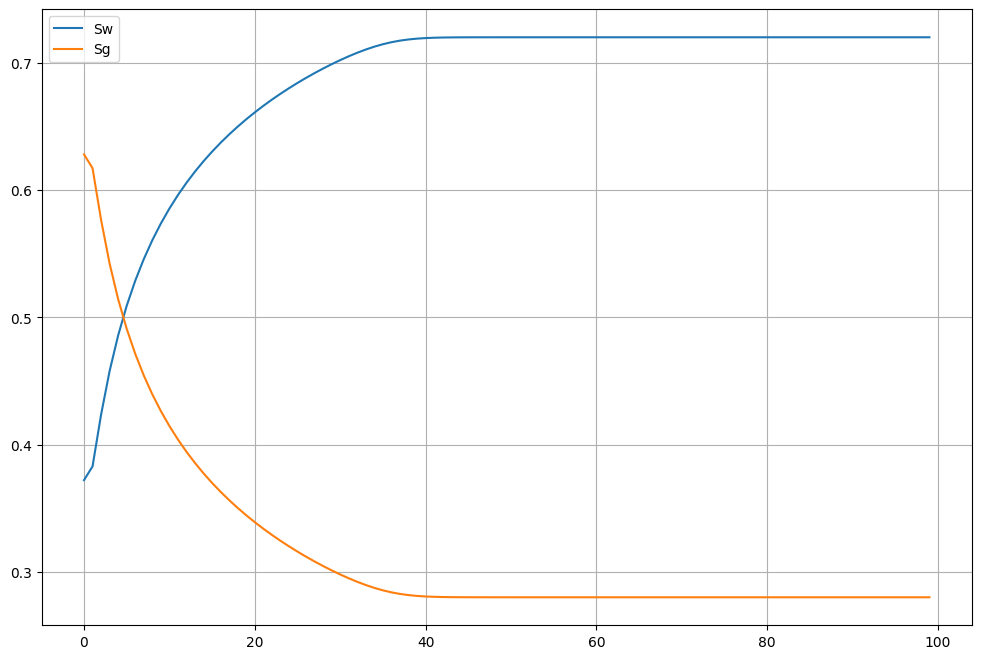

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,8))

plt.plot(Sw_matrix[-1][:], label = "Sw")
plt.plot(Sg_matrix[-1][:], label = "Sg")
plt.legend()
plt.grid()
plt.show()

In [17]:
p = p.drop(0)

In [19]:
p['delta_p'] = p['p_inicio'] - p['p_fim']

In [20]:
p['delta_p_exp'] = p['delta_p'] + np.random.normal(0, 0.48, size = p['delta_p'].size)

In [21]:
p['delta_p_exp']

1      333.112737
2      332.758932
3      332.394902
4      332.814971
5      331.670952
          ...    
146    292.106188
147    291.534878
148    291.849742
149    290.972739
150    291.593422
Name: delta_p_exp, Length: 150, dtype: float64

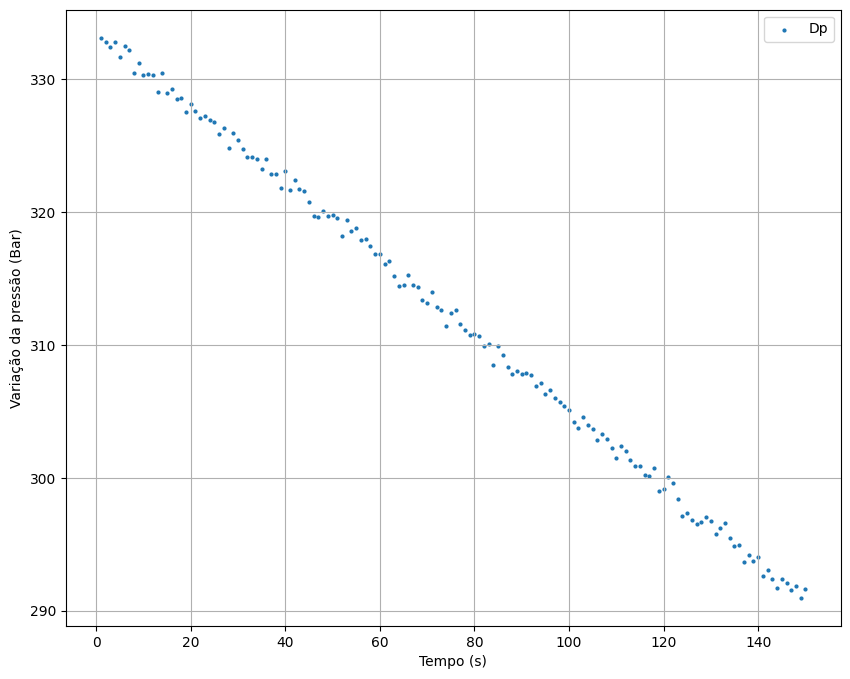

In [22]:
plt.figure(figsize = (10,8))
plt.scatter(p['t'],p['delta_p_exp'], label = "Dp", s = 4)
plt.xlabel("Tempo (s)")
plt.ylabel("Variação da pressão (Bar)")
plt.legend()
plt.grid()

In [23]:
delta_p = pd.DataFrame(data = p['delta_p_exp'])

In [24]:
delta_p = delta_p.reset_index(drop = True)
delta_p.to_csv("delta_p_exp.csv")